# Introducción y preámbulo


El paper dice:

> CLNews comprises 300 propagation trees. The dataset is fully
available at https://doi.org/10.5281/zenodo.5851205. For each propa-
gation tree, we release two files. The first is a JSON file that encodes
timestamps, tweet ids, and author ids. The second type of file shows
the propagation tree. The file structure considers a top-down list of
edges. Each edge shows the relationship between each child node
and its parent, showing the timestamp (relative to the parent) when
the edge was created. These files are organized into four folders,
each grouping a veracity category.

In [1]:
import os
import sys
from pathlib import Path


DATA_PATH = Path("data") / "CLNews"
DATA_PATH

PosixPath('data/CLNews')

In [37]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from chiricoca.config import setup_style
setup_style(dpi=192)

# Entender los datos

In [3]:
import json

In [4]:
str(DATA_PATH / '*' / '*')

'data/CLNews/*/*'

In [5]:
from glob import glob
event_dirs = glob(str(DATA_PATH / '*' / '*'))
event_dirs[0]

'data/CLNews/False rumor/1229927858631585792'

In [6]:
current_event = event_dirs[0]
event_type = current_event.split('/')[-2]
event_id = current_event.split('/')[-1]
event_type, event_id

('False rumor', '1229927858631585792')

In [7]:
json_file = Path(current_event) / f'{event_id}.json'

!head "{json_file}" -n 25

{
  "Tweets": [
    {
      "id_evento": "1229928884688302081",
      "id_usuario": "583de9425a512f294f6b10fdb183f17b",
      "Tweets": [
        {
          "id_evento": "1229931128225697793",
          "id_usuario": "7b471f82f8b974476f41b1d2e01cc269",
          "Tweets": [
            {
              "id_evento": "1229933274182582272",
              "id_usuario": "584b11b36897d507ddd466bee128f809",
              "Tweets": [],
              "Retweets": [
                {
                  "id_evento": "1229937945907486721",
                  "id_usuario": "449ec0b5a2d2b8e523a49fc36f426aa3"
                },
                {
                  "id_evento": "1230005587490066432",
                  "id_usuario": "a9675fb8ad7903edef627881d0763d40"
                },
                {
                  "id_evento": "1230034119767285760",


In [8]:
with open(json_file, 'rt', encoding='utf-8-sig') as f:
    tweets_raw = json.loads(f.read())

tweets_raw.keys()

dict_keys(['Tweets', 'Retweets'])

In [9]:
rts = pd.DataFrame(tweets_raw['Retweets'])
rts

,id_evento,id_usuario
0,1229928702835920898,583de9425a512f294f6b10fdb183f17b
1,1229928915793334274,fc6387b5724417418658a9d99243d42d
2,1229929442266558464,8ab5567f24ee072e1eb0e43b15dec1b3
3,1229929493697089536,623a4df543a7c1ea08bd655a62e99f13
4,1229931248912666625,89fc42254d903066cc9d258debf24a36
...,...,...
1150,1231679872759746560,1de02df907e789498f429d883c81bb16
1151,1231688265981472768,f6b46801021d52ca5c12f27d6df5eda6
1152,1231693531661635590,b62145b4d0eede90f42fb95a83151087
1153,1231704703819550720,cf5f3b70c6134c06179349fd59db561f


In [10]:
tweets = pd.DataFrame(tweets_raw['Tweets'])
tweets

,id_evento,id_usuario,Tweets,Retweets
0,1229928884688302081,583de9425a512f294f6b10fdb183f17b,"[{'id_evento': '1229931128225697793', 'id_usua...","[{'id_evento': '1229930927863799810', 'id_usua..."
1,1229930342968066049,6f07cf147f4e4f2360d099f92549e8aa,[],"[{'id_evento': '1229930894418468864', 'id_usua..."
2,1229931229279117315,aa8b3eb1ec3c98dfd2bf61ef50c12bcb,"[{'id_evento': '1229973832166977543', 'id_usua...","[{'id_evento': '1229949629099323392', 'id_usua..."
3,1229932456272367623,8d2dcd9559e5eafd9d32f5a039c5b1db,"[{'id_evento': '1229934273785925632', 'id_usua...","[{'id_evento': '1229933839113388033', 'id_usua..."
4,1229932730131021827,85f008e43d47c66df682f5cc80a39e83,"[{'id_evento': '1229934088972357632', 'id_usua...","[{'id_evento': '1229948827412680704', 'id_usua..."
...,...,...,...,...
201,1231568351622782978,fc6387b5724417418658a9d99243d42d,"[{'id_evento': '1231572850827550721', 'id_usua...","[{'id_evento': '1231573536059330560', 'id_usua..."
202,1231582673585438723,17f5a3230930b2d8111fc086f7ba9420,[],[]
203,1231603610800283648,134e38248c0da322687fb0efd30a3267,[],[]
204,1231660288593858561,3226c581f4bb9216ca886c854aad39a7,[],[]


In [11]:
tweets['Retweets'].map(len).sum()

211

In [12]:
tree_file = Path(current_event) / f'{event_id}_r.min'

!head "{tree_file}" -n 5

raiz: ['1229927858631585792','0.00']->['ROOT',0.00]
retweet: ['1229928702835920898','3.35']->['1229927858631585792','0.0']
retweet: ['1229928915793334274','4.20']->['1229927858631585792','0.0']
retweet: ['1229929442266558464','6.28']->['1229927858631585792','0.0']
retweet: ['1229929493697089536','6.48']->['1229927858631585792','0.0']


In [13]:
import pandas as pd
import re

def tree_file_to_dataframe(file_path):
    """
    Convierte un archivo de árbol de interacciones en un DataFrame de pandas.
    
    Args:
        file_path: Ruta al archivo de árbol
        
    Returns:
        DataFrame con columnas: source, target, time, interaction_type
    """
    # Listas para almacenar los datos
    sources = []
    targets = []
    times = []
    interaction_types = []
    
    # Expresión regular para extraer los datos
    pattern = r'(\w+): \[\'([\d\.]+)\',\'([\d\.]+)\'\]->\[\'([\w\d\.]+)\',\'?([\d\.]+)\'?\]'
    
    # Leer el archivo
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            match = re.match(pattern, line)
            
            if match:
                interaction_type = match.group(1)  # tipo de interacción (raiz, retweet)
                source_id = match.group(2)        # ID del nodo hijo
                source_time = float(match.group(3))  # tiempo del nodo hijo
                target_id = match.group(4)        # ID del nodo padre
                target_time = float(match.group(5))  # tiempo del nodo padre
                
                # Tiempo relativo entre nodo hijo y padre
                relative_time = source_time - target_time
                
                sources.append(source_id)
                targets.append(target_id)
                times.append(relative_time)
                interaction_types.append(interaction_type)
    
    # Crear el DataFrame
    df = pd.DataFrame({
        'source': sources,
        'target': targets,
        'time': times,
        'interaction_type': interaction_types
    })
    
    return df


df = tree_file_to_dataframe(tree_file)
df

,source,target,time,interaction_type
0,1229927858631585792,ROOT,0.00,raiz
1,1229928702835920898,1229927858631585792,3.35,retweet
2,1229928915793334274,1229927858631585792,4.20,retweet
3,1229929442266558464,1229927858631585792,6.28,retweet
4,1229929493697089536,1229927858631585792,6.48,retweet
...,...,...,...,...
1687,1231572850827550721,1231568351622782978,17.87,reply
1688,1231582673585438723,1229927858631585792,6575.63,reply
1689,1231603610800283648,1229927858631585792,6658.83,reply
1690,1231660288593858561,1229927858631585792,6884.05,reply


# Construir el _dataset_

In [14]:
all_events = []
trees = []

for current_event in event_dirs:
    event_type = current_event.split('/')[-2]
    event_id = current_event.split('/')[-1]

    json_file = Path(current_event) / f'{event_id}.json'
    
    with open(json_file, 'rt', encoding='utf-8-sig') as f:
        tweets_raw = json.loads(f.read())

    all_events.append(pd.DataFrame(tweets_raw['Tweets']).assign(event_type=event_type, event_id=event_id))

    tree_file = Path(current_event) / f'{event_id}_r.min'
    trees.append(tree_file_to_dataframe(tree_file).assign(event_type=event_type, event_id=event_id))

all_events = pd.concat(all_events)
trees = pd.concat(trees)
all_events

,id_evento,id_usuario,Tweets,Retweets,event_type,event_id
0,1229928884688302081,583de9425a512f294f6b10fdb183f17b,"[{'id_evento': '1229931128225697793', 'id_usua...","[{'id_evento': '1229930927863799810', 'id_usua...",False rumor,1229927858631585792
1,1229930342968066049,6f07cf147f4e4f2360d099f92549e8aa,[],"[{'id_evento': '1229930894418468864', 'id_usua...",False rumor,1229927858631585792
2,1229931229279117315,aa8b3eb1ec3c98dfd2bf61ef50c12bcb,"[{'id_evento': '1229973832166977543', 'id_usua...","[{'id_evento': '1229949629099323392', 'id_usua...",False rumor,1229927858631585792
3,1229932456272367623,8d2dcd9559e5eafd9d32f5a039c5b1db,"[{'id_evento': '1229934273785925632', 'id_usua...","[{'id_evento': '1229933839113388033', 'id_usua...",False rumor,1229927858631585792
4,1229932730131021827,85f008e43d47c66df682f5cc80a39e83,"[{'id_evento': '1229934088972357632', 'id_usua...","[{'id_evento': '1229948827412680704', 'id_usua...",False rumor,1229927858631585792
...,...,...,...,...,...,...
1961,1196290370583302145,663aad1b06fa153b0bee82fb3c9b9179,[],[],Unverified,1195111297077202946
1962,1196408166499717122,d0542ab567d36dce0d9b6df858e505ce,[],[],Unverified,1195111297077202946
1963,1196421810528673792,a0f2b51c4fc540ad097cc189aee9ad17,[],[],Unverified,1195111297077202946
1964,1196470436680351744,46eab96efe8a1306d542b81a40a8d516,[],[],Unverified,1195111297077202946


In [15]:
trees

,source,target,time,interaction_type,event_type,event_id
0,1229927858631585792,ROOT,0.00,raiz,False rumor,1229927858631585792
1,1229928702835920898,1229927858631585792,3.35,retweet,False rumor,1229927858631585792
2,1229928915793334274,1229927858631585792,4.20,retweet,False rumor,1229927858631585792
3,1229929442266558464,1229927858631585792,6.28,retweet,False rumor,1229927858631585792
4,1229929493697089536,1229927858631585792,6.48,retweet,False rumor,1229927858631585792
...,...,...,...,...,...,...
3562,1196290370583302145,1195111297077202946,4685.23,reply,Unverified,1195111297077202946
3563,1196408166499717122,1195111297077202946,5153.30,reply,Unverified,1195111297077202946
3564,1196421810528673792,1195111297077202946,5207.52,reply,Unverified,1195111297077202946
3565,1196470436680351744,1195111297077202946,5400.75,reply,Unverified,1195111297077202946


Text(0.0, 1.0, 'Cantidad de publicaciones por tipo de evento')

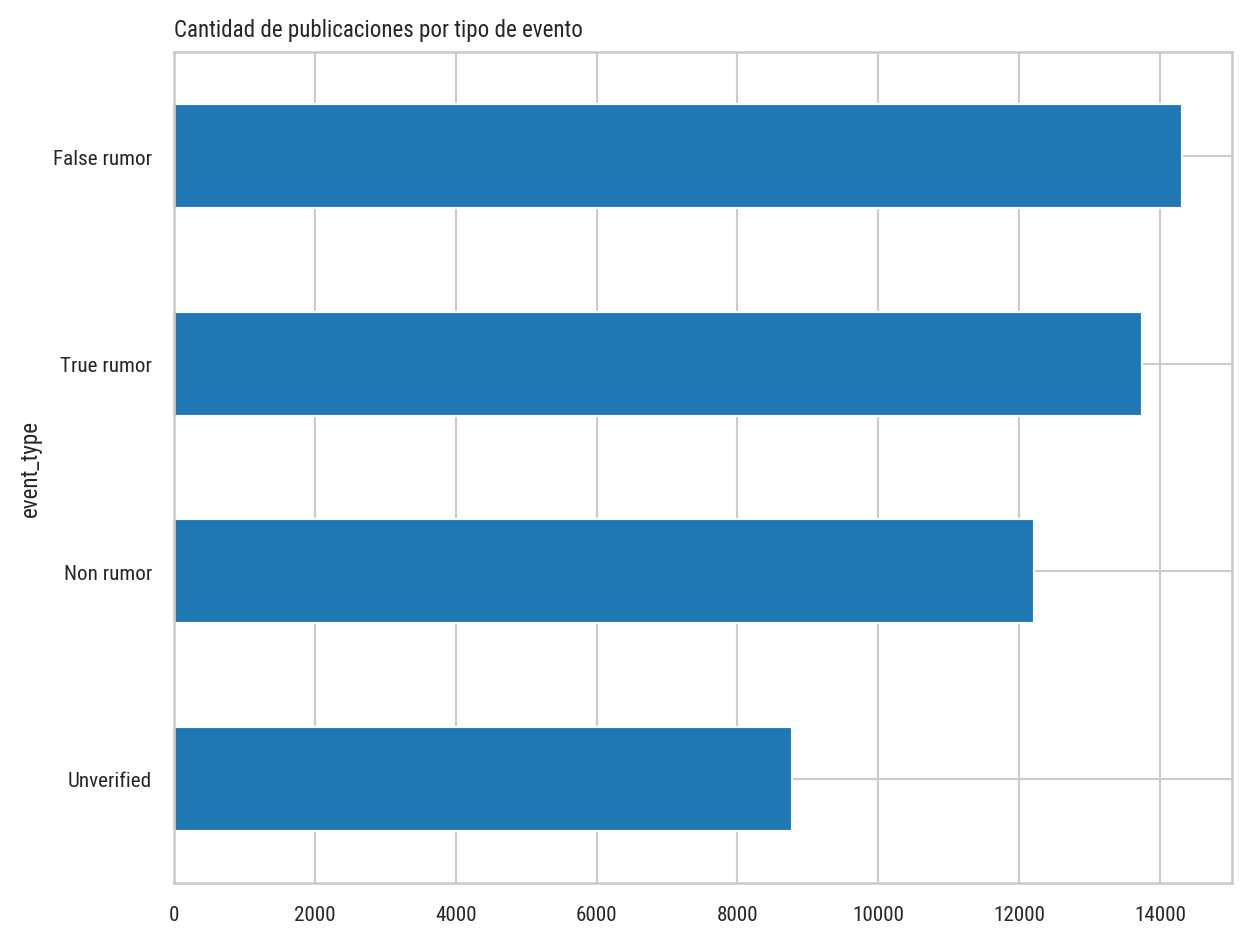

In [39]:
fig, ax = plt.subplots()
all_events['event_type'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Cantidad de publicaciones por tipo de evento', loc='left')

In [17]:
trees.groupby('event_type').size()

event_type
False rumor    119025
Non rumor       71088
True rumor      96677
Unverified      53716
dtype: int64

Text(0.0, 1.0, 'Tipos de difusión por evento')

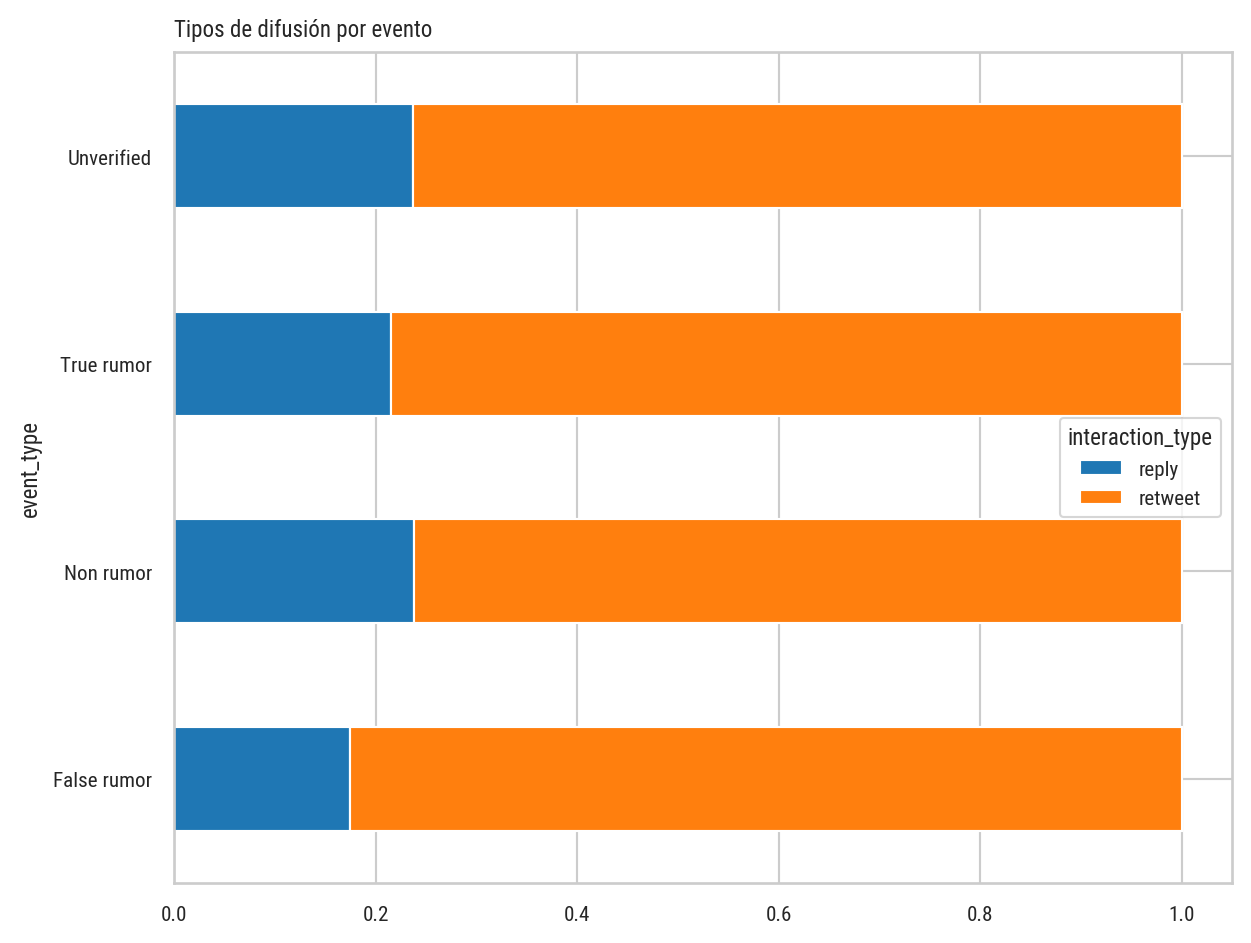

In [40]:
from chiricoca.base.weights import normalize_rows

fig, ax = plt.subplots()

trees[trees["interaction_type"] != "raiz"].groupby(
    ["event_type", "interaction_type"]
).size().unstack().pipe(normalize_rows).plot(kind="barh", stacked=True, ax=ax)

ax.set_title("Tipos de difusión por evento", loc="left")

Text(0.5, 0, 'time [s]')

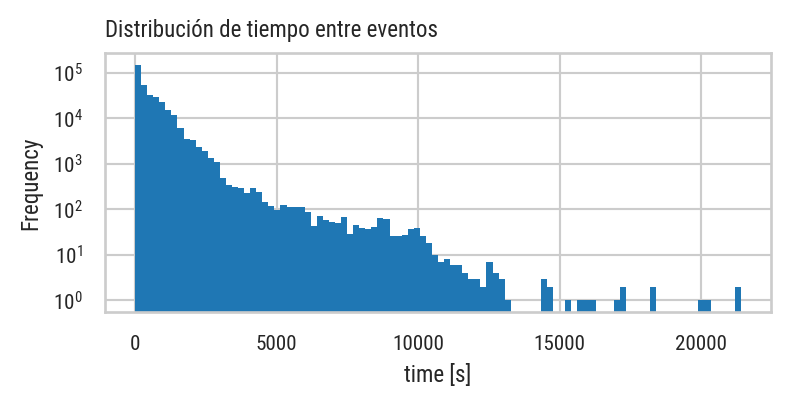

In [41]:
fig, ax = plt.subplots(figsize=(4, 2))
trees[trees['interaction_type'] != 'raiz']['time'].plot(kind='hist', bins=100, ax=ax, edgecolor='none')
ax.set_yscale('log')
ax.set_title('Distribución de tiempo entre eventos', loc='left')
ax.set_xlabel('time [s]')

Text(0.0, 1.0, 'Tiempo de propagación')

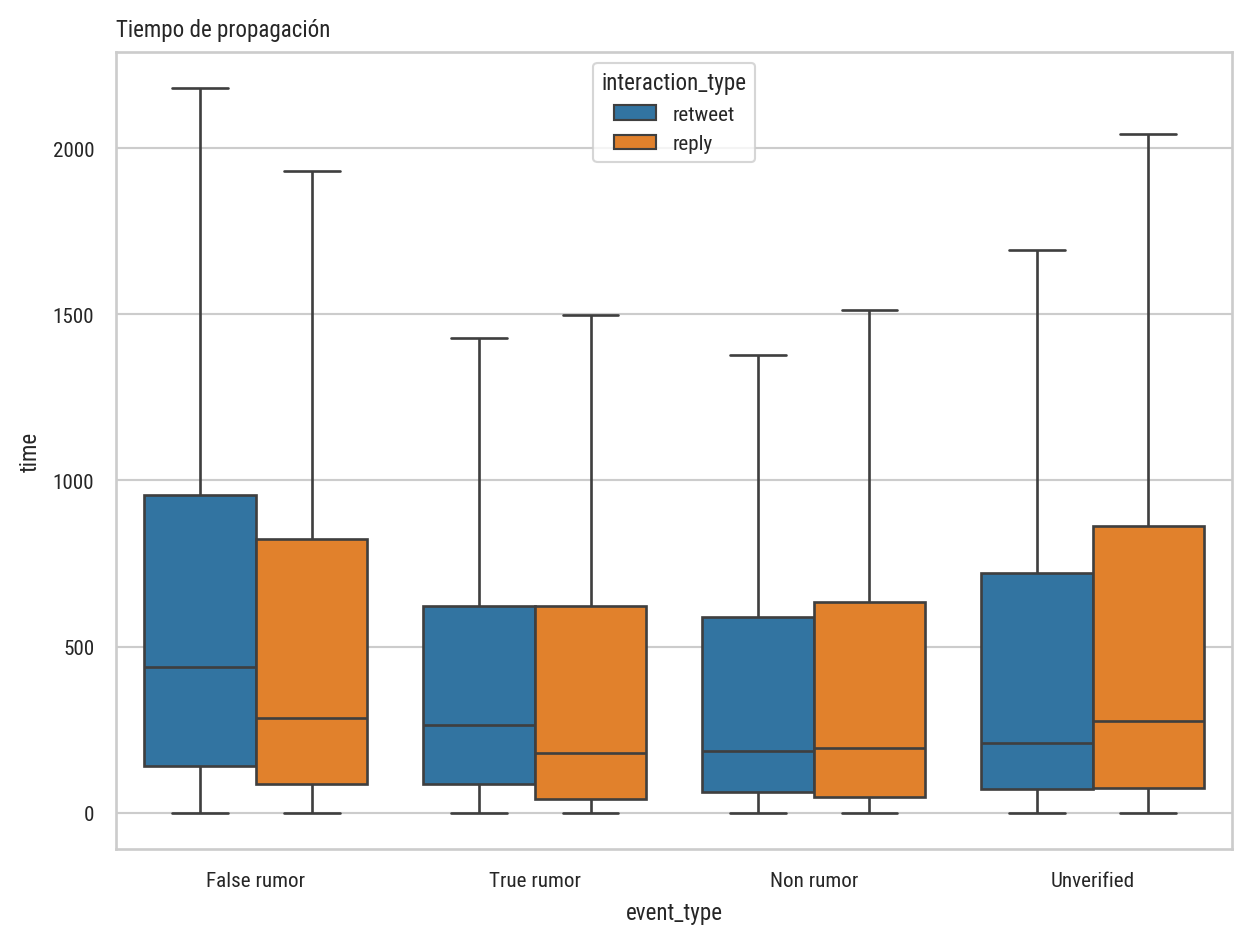

In [42]:
fig, ax = plt.subplots()

sns.boxplot(trees[trees["interaction_type"] != "raiz"], x='event_type', hue='interaction_type', y='time', showfliers=False, ax=ax)
ax.set_title('Tiempo de propagación', loc='left')

In [22]:
import networkx as nx

networks = {}

for idx, group in trees.groupby('event_id'):
    networks[idx] = nx.from_pandas_edgelist(group, source='target', target='source', edge_attr=['time'])

networks[idx]

In [24]:
def network_summary(G):
    n_nodes = G.number_of_nodes()
    heights = nx.single_source_shortest_path_length(G, 'ROOT')
    max_height = max(heights.values())
    
    # Contar nodos por nivel para obtener ancho máximo
    levels = {}
    for node, depth in heights.items():
        levels[depth] = levels.get(depth, 0) + 1
    max_width = max(levels.values())
    
    # Ratio de hojas
    leaves = sum(1 for node in G.nodes() if G.degree(node) == 1 and node != 'ROOT')
    leaf_ratio = leaves / n_nodes
    
    return {
        'nodes': n_nodes,
        'height': max_height,
        'max_width': max_width,
        'leaf_ratio': leaf_ratio,
        'avg_degree': sum(dict(G.degree()).values()) / n_nodes
    }

In [26]:
trees

,source,target,time,interaction_type,event_type,event_id
0,1229927858631585792,ROOT,0.00,raiz,False rumor,1229927858631585792
1,1229928702835920898,1229927858631585792,3.35,retweet,False rumor,1229927858631585792
2,1229928915793334274,1229927858631585792,4.20,retweet,False rumor,1229927858631585792
3,1229929442266558464,1229927858631585792,6.28,retweet,False rumor,1229927858631585792
4,1229929493697089536,1229927858631585792,6.48,retweet,False rumor,1229927858631585792
...,...,...,...,...,...,...
3562,1196290370583302145,1195111297077202946,4685.23,reply,Unverified,1195111297077202946
3563,1196408166499717122,1195111297077202946,5153.30,reply,Unverified,1195111297077202946
3564,1196421810528673792,1195111297077202946,5207.52,reply,Unverified,1195111297077202946
3565,1196470436680351744,1195111297077202946,5400.75,reply,Unverified,1195111297077202946


In [30]:
trees[['event_id', 'event_type']].drop_duplicates()

,event_id,event_type
0,1229927858631585792,False rumor
0,1207449421811601408,False rumor
0,1152999063920488448,False rumor
0,1194996116661690369,False rumor
0,1203494375042498561,False rumor
...,...,...
0,1183810053075341312,Unverified
0,1145345048286040066,Unverified
0,1147596036959064064,Unverified
0,1191485804973088768,Unverified


In [31]:
network_stats = (
    pd.DataFrame.from_records(list(map(network_summary, networks.values())))
    .assign(event_id=networks.keys())
    .merge(trees.groupby('event_id')['time'].mean().rename('mean_time').reset_index())
    .merge(trees[['event_id', 'event_type']].drop_duplicates())
)
network_stats

,nodes,height,max_width,leaf_ratio,avg_degree,event_id,mean_time,event_type
0,389,8,309,0.856041,1.994859,1143327598342234122,236.437191,Non rumor
1,524,5,496,0.965649,1.996183,1143548489592295424,475.618412,Non rumor
2,5,2,3,0.600000,1.600000,1143715189189165058,15.955000,True rumor
3,252,5,230,0.948413,1.992063,1144738005090996235,11.694427,Non rumor
4,65,4,53,0.861538,1.969231,1144752642838716419,14.357031,Non rumor
...,...,...,...,...,...,...,...,...
295,1051,6,699,0.916270,1.998097,1211845382679998464,419.122848,True rumor
296,699,17,595,0.902718,1.997139,1212216244226678785,556.227650,Non rumor
297,1515,4,1302,0.994059,1.998680,1212522565043937286,398.333639,True rumor
298,689,10,643,0.962264,1.997097,1212789306265362434,733.887733,True rumor


/home/egraells/miniconda3/envs/aves/lib/python3.10/site-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try kdeplot.
  warnings.warn(msg, UserWarning)
/home/egraells/miniconda3/envs/aves/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


(1, 10000)

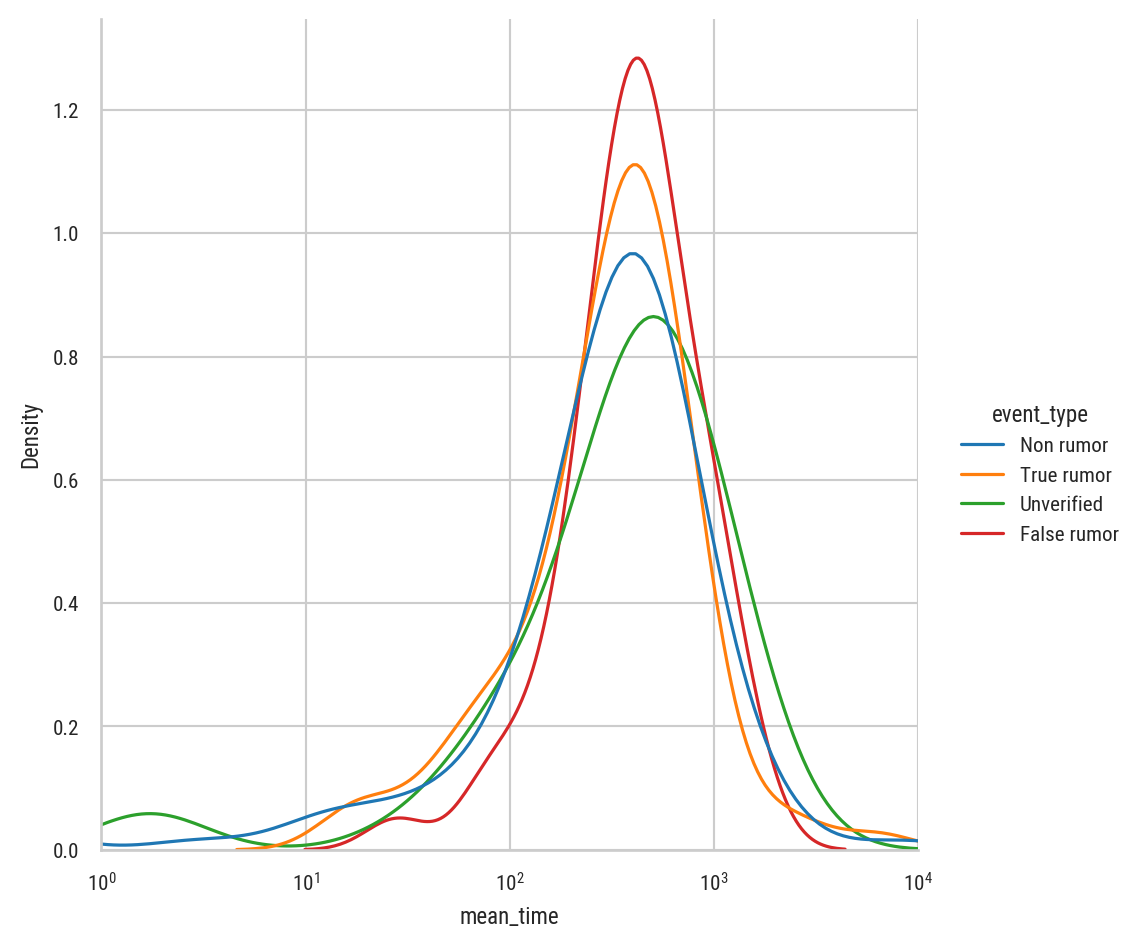

In [48]:
g = sns.displot(network_stats, ax=ax, x='mean_time', kind='kde', log_scale=True, cumulative=False, common_norm=False, hue='event_type', common_grid=False)
g.ax.set_xlim([1, 10000])

Text(0.0, 1.0, 'Anchura')

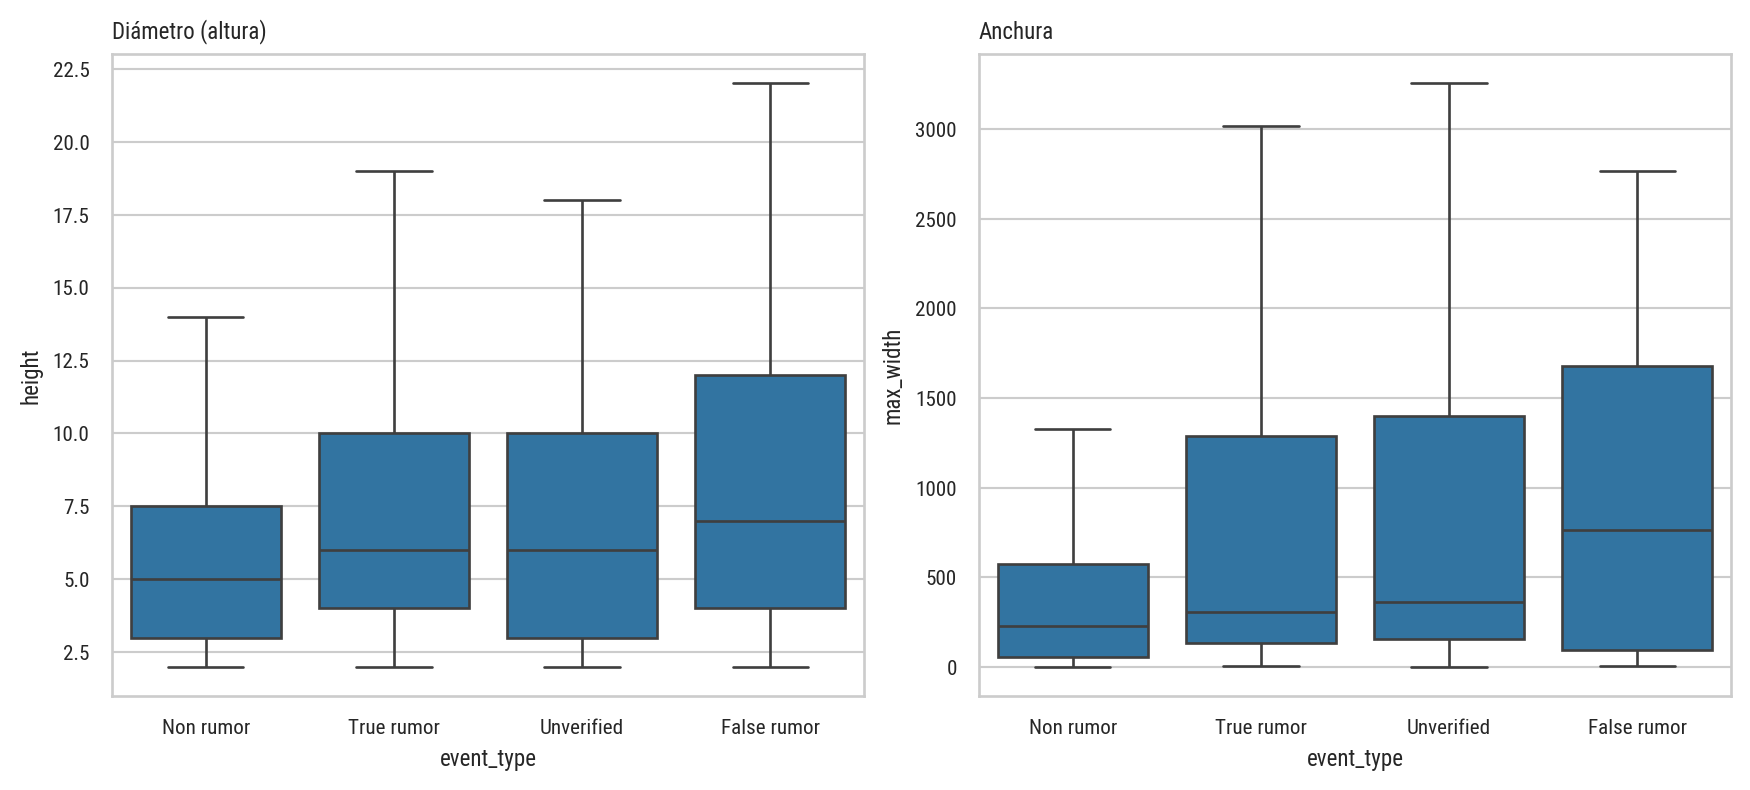

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.boxplot(network_stats, x='event_type', y='height', showfliers=False, ax=axes[0])
axes[0].set_title('Diámetro (altura)', loc='left')

sns.boxplot(network_stats, x='event_type', y='max_width', showfliers=False, ax=axes[1])
axes[1].set_title('Anchura', loc='left')

In [51]:
import random

random_ids = random.sample(list(networks.keys()), 28)
random_ids

['1146468651773702146',
 '1194989136274440193',
 '1146178255822708738',
 '1196633655587815425',
 '1151918232233795585',
 '1184122051323465729',
 '1174867997271478272',
 '1199001840685330432',
 '1175098700609261570',
 '1172849953770790913',
 '1211845382679998464',
 '1191514671863517185',
 '1196622510395138049',
 '1187098993379160065',
 '1212522565043937286',
 '1144772676373950465',
 '1212789306265362434',
 '1173586888696967168',
 '1211027486265499648',
 '1196912248700186626',
 '1188907490571882497',
 '1147593398498603011',
 '1149895300812804096',
 '1194307124664422401',
 '1196009775701643264',
 '1183134595883192321',
 '1152968903930404864',
 '1187086859966570496']

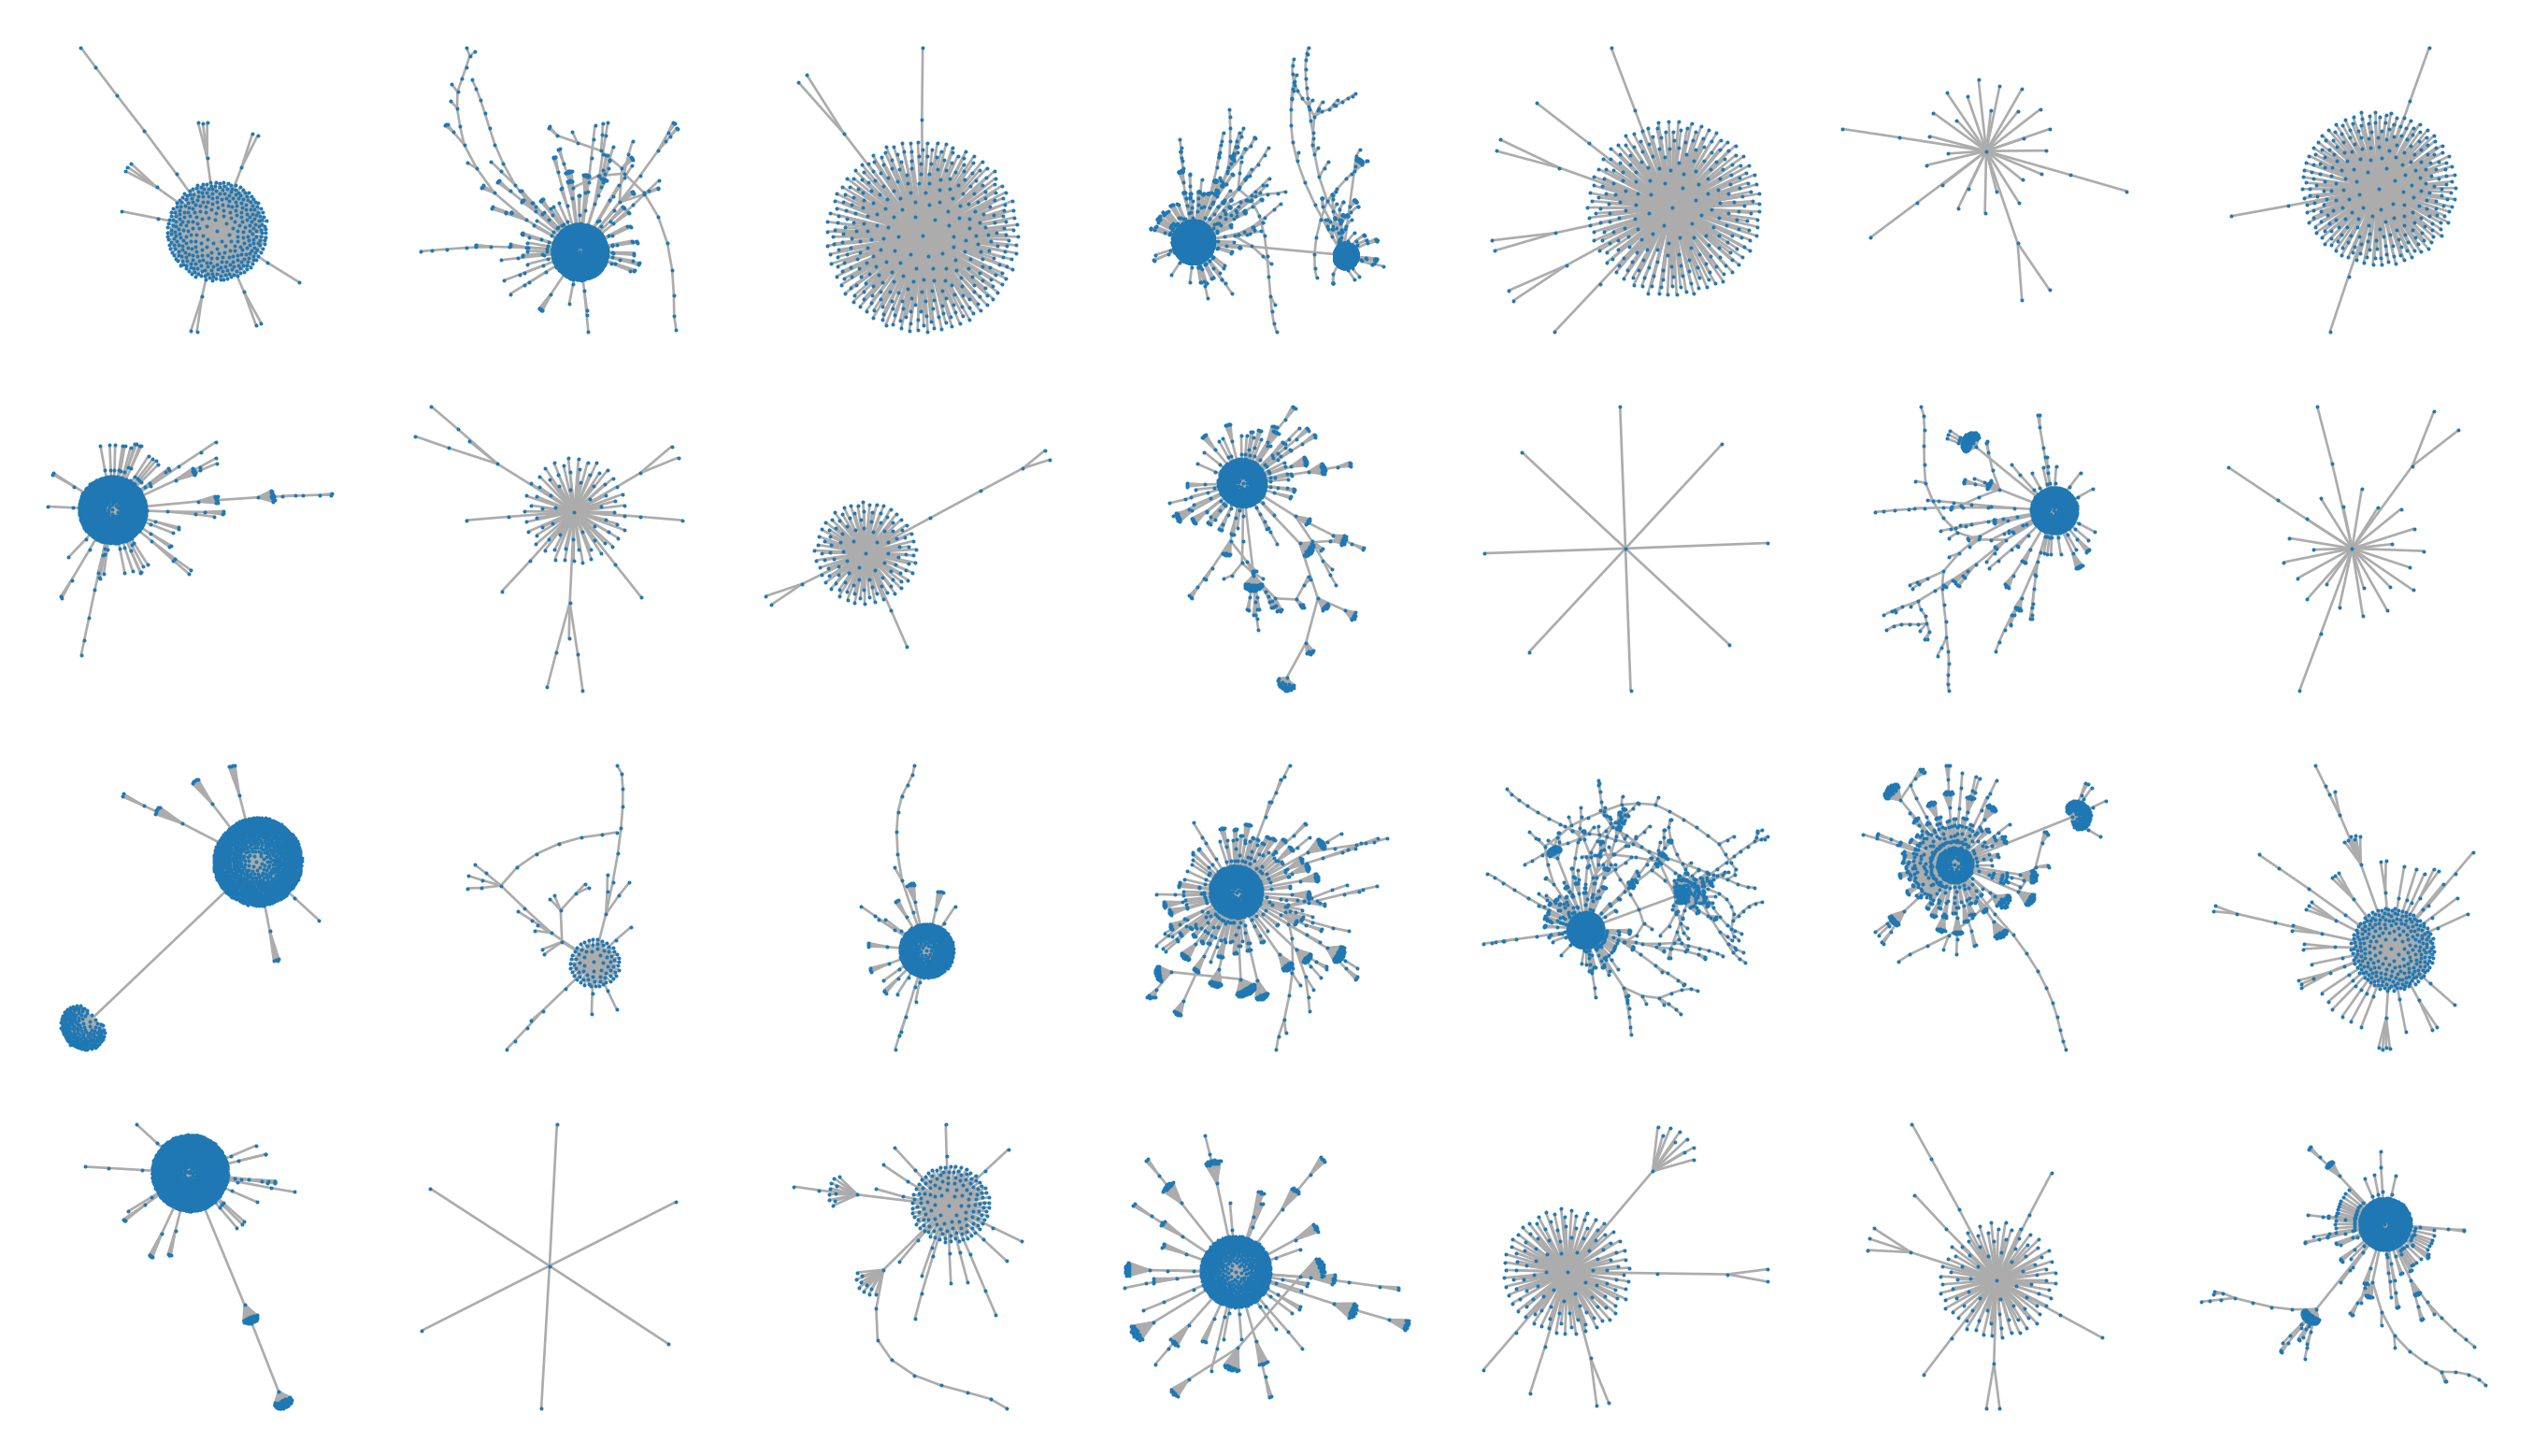

In [52]:
fig, axes = plt.subplots(4, 7, figsize=(14, 8))

for net_id, ax in zip(random_ids, axes.flatten()):

    nx.draw_networkx(networks[net_id], node_size=1, with_labels=False, ax=ax, edge_color='#abacab', linewidths=0.5)


    ax.set_axis_off()
    ax.set_aspect('equal')